In [70]:
import matplotlib.pyplot as plt
from medmnist import PathMNIST
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
sns.set_theme(style = "whitegrid")

Firstly, we divide the PathMNIST dataset into train and test subsets and explore their sizes.

In [71]:
train_dataset = PathMNIST(split = 'train',
                        transform = None,
                        download = True)
test_dataset = PathMNIST(split = 'test',
                        transform = None,
                        download = True)

train_images = train_dataset.imgs
test_images = test_dataset.imgs

print(f"Loaded {train_images.shape[0]} training images and {test_images.shape[0]} of shape {train_images.shape[1:]}")

Loaded 89996 training images and 7180 of shape (28, 28, 3)


Then, we explore possible labels in our data and their frequency. 

Possible data classes in both test and train are: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']
[ 9366  9509 10360 10401  8006 12182  7886  9401 12885]


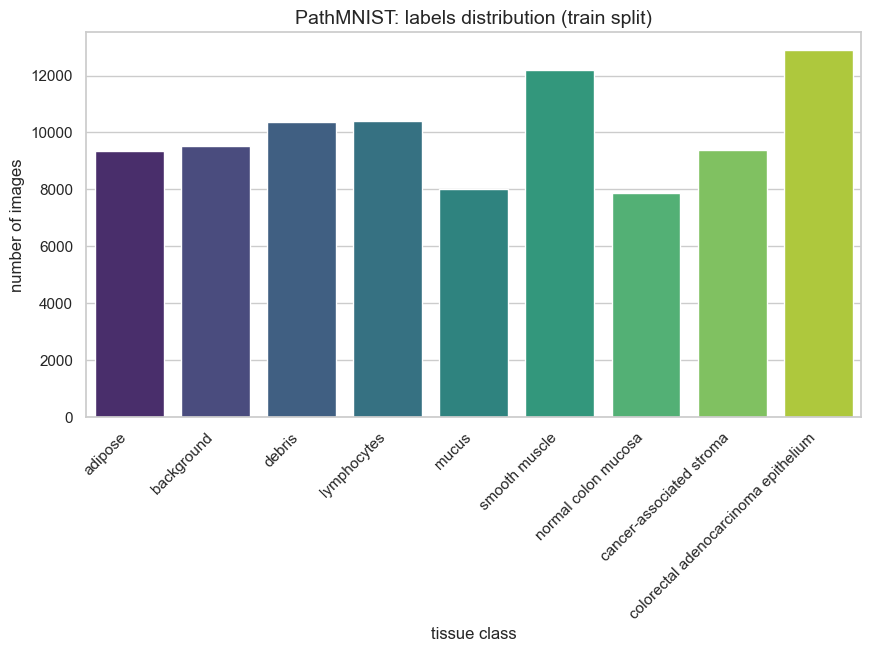

In [72]:
train_labels = train_dataset.labels.squeeze()
test_labels = test_dataset.labels.squeeze()

train_labels_dict = train_dataset.info['label']
test_labels_dict = test_dataset.info['label']

class_names = [train_labels_dict[str(i)] for i in range(len(train_labels_dict))]
print(f"Possible data classes in both test and train are: {class_names}")

unique, train_counts = np.unique(train_labels, return_counts = True)
unique, test_counts = np.unique(train_labels, return_counts = True)

print(train_counts)
plt.figure(figsize = (10, 5))
sns.barplot(x = [class_names[i] for i in unique], y = train_counts, hue = [class_names[i] for i in unique], palette = "viridis")
plt.title("PathMNIST: labels distribution (train split)", fontsize=14)
plt.xlabel("tissue class", fontsize = 12)
plt.ylabel("number of images", fontsize = 12)
plt.xticks(rotation = 45, ha = 'right')
plt.show()

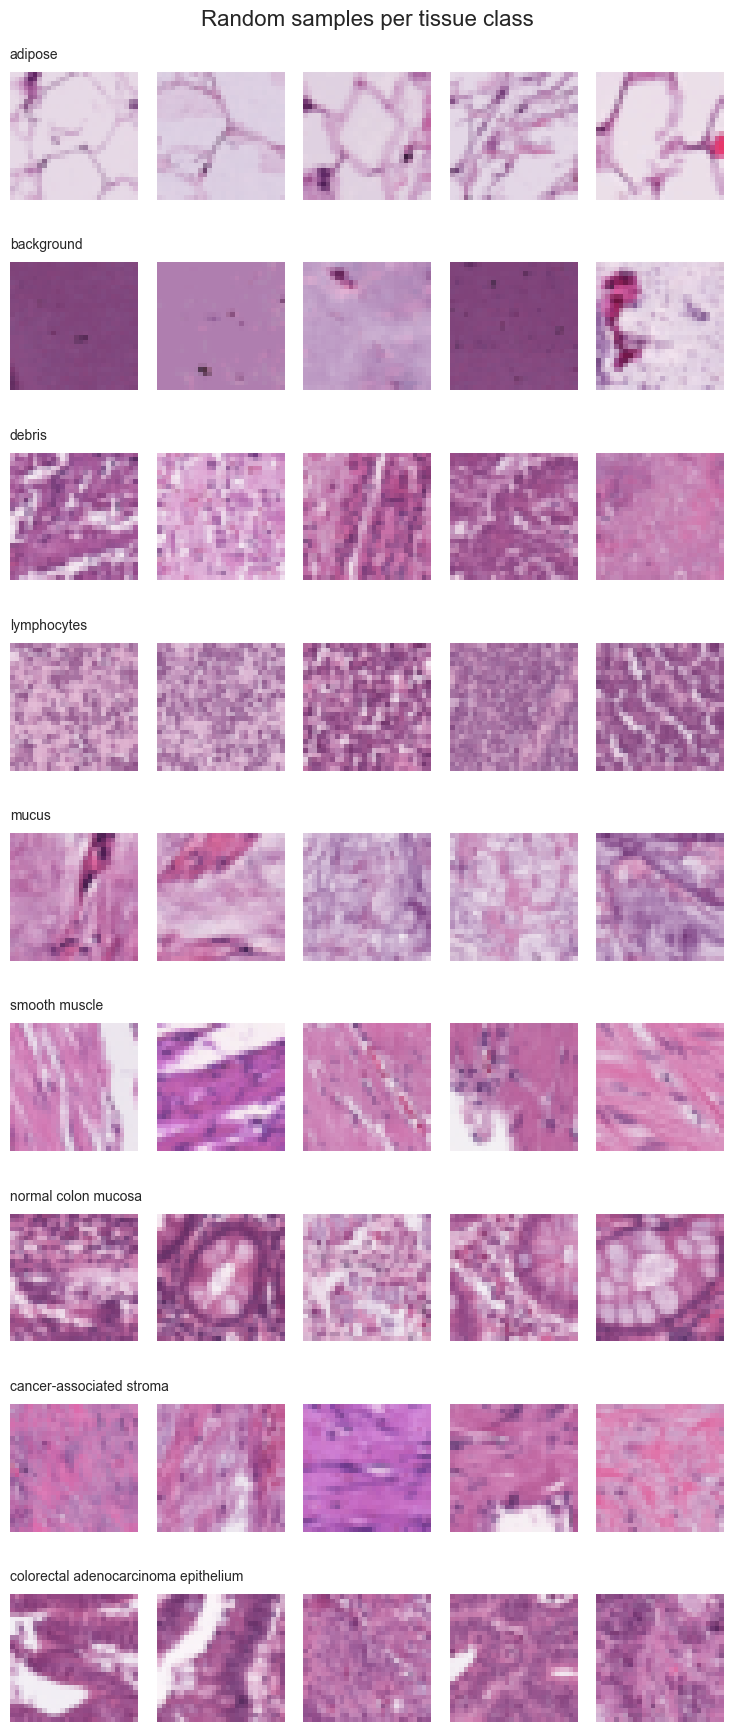

In [73]:
samples_per_class = 5
num_classes = len(class_names)

fig, axes = plt.subplots(num_classes, samples_per_class, figsize = (samples_per_class * 1.5, num_classes * 2))

for class_idx in range(num_classes):
    class_indices = np.where(train_labels == class_idx)[0]
    selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)
    
    for i, idx in enumerate(selected_indices):
        ax = axes[class_idx, i]
        ax.imshow(train_images[idx])
        ax.axis('off')
        if i == 0:
            ax.set_title(class_names[class_idx], fontsize = 10, loc = 'left', pad = 10)
            
plt.suptitle("Random samples per tissue class", fontsize = 16)
plt.tight_layout(h_pad = 0.1, w_pad = 0.1)
plt.show()

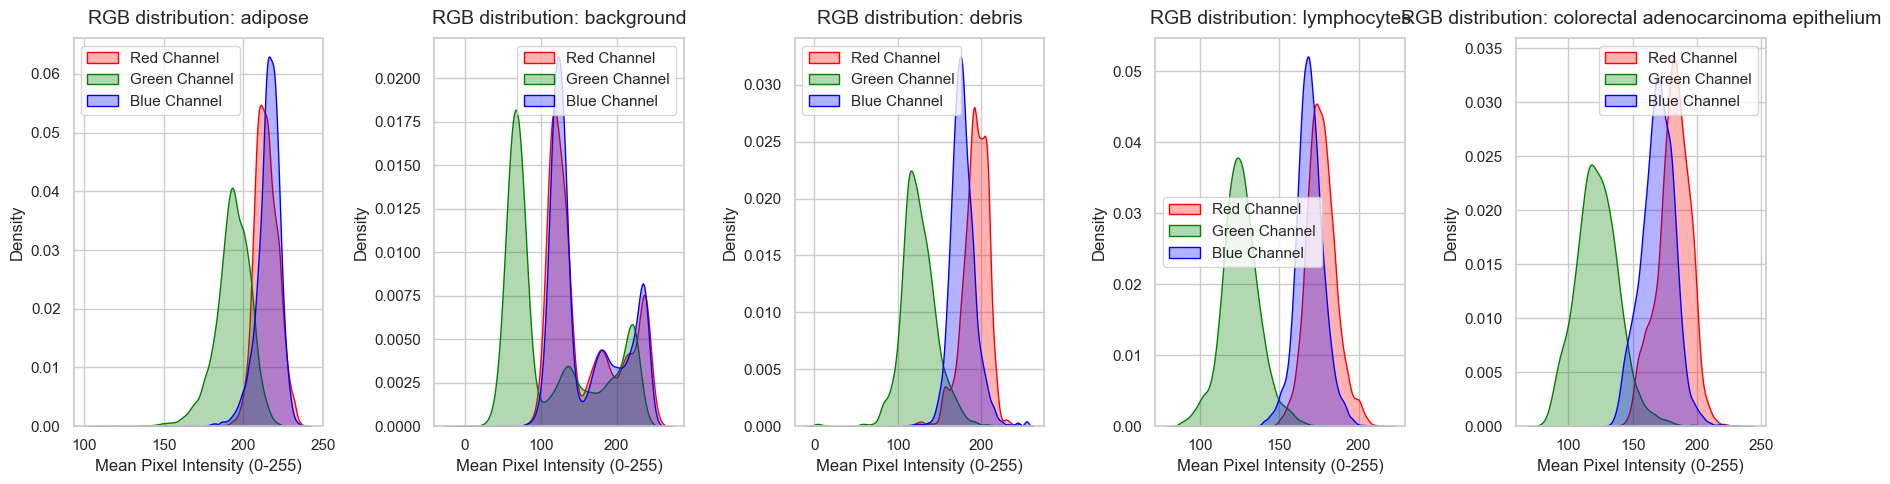

In [74]:
mean_r = np.mean(train_images[:, :, :, 0], axis = (1, 2))
mean_g = np.mean(train_images[:, :, :, 1], axis = (1, 2))
mean_b = np.mean(train_images[:, :, :, 2], axis = (1, 2))

# choosing the most distinct classes: adipose, background, debris and colorectal adenocarcinoma epithelium
target_classes = [0, 1, 2, 3, 8] 
fig, axes = plt.subplots(1, len(target_classes), figsize=(18, 5))

for idx, c in enumerate(target_classes):
    class_mask = (train_labels == c)
    
    sns.kdeplot(mean_r[class_mask], ax = axes[idx], color = 'red', label = 'Red Channel', fill = True, alpha = 0.3)
    sns.kdeplot(mean_g[class_mask], ax = axes[idx], color = 'green', label = 'Green Channel', fill = True, alpha = 0.3)
    sns.kdeplot(mean_b[class_mask], ax = axes[idx], color = 'blue', label = 'Blue Channel', fill = True, alpha = 0.3)
    
    axes[idx].set_title(f"RGB distribution: {class_names[c]}", fontsize = 14, pad = 10)
    axes[idx].set_xlabel("Mean Pixel Intensity (0-255)")
    axes[idx].set_ylabel("Density")
    axes[idx].legend()
    
plt.tight_layout()
plt.show()

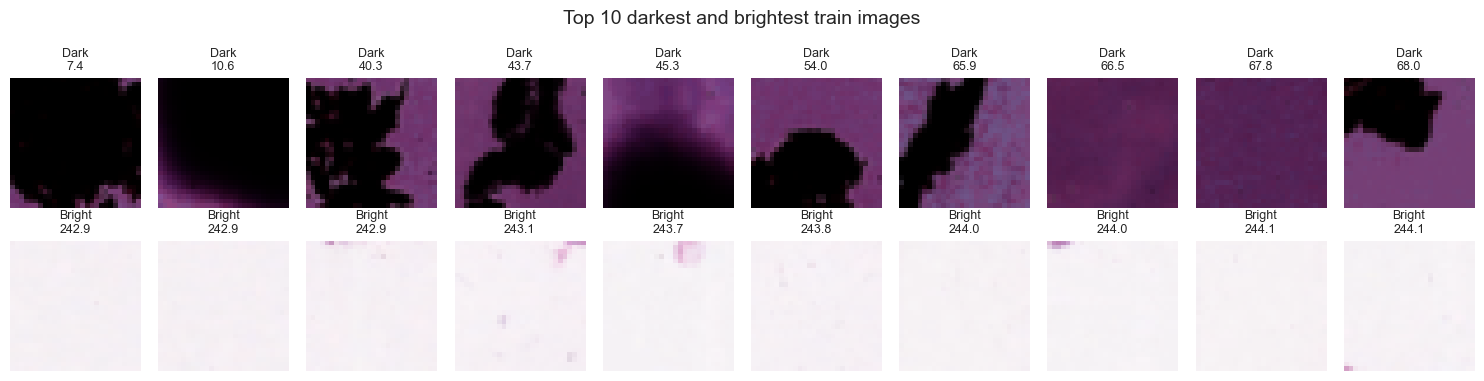

In [75]:
imgs_per_extremum = 10
mean_intensities = np.mean(train_images, axis = (1, 2, 3))
sorted_indices = np.argsort(mean_intensities)
darkest_indices = sorted_indices[:imgs_per_extremum]
brightest_indices = sorted_indices[-imgs_per_extremum:]

fig, axes = plt.subplots(2, imgs_per_extremum, figsize=(15, 4))

for i, idx in enumerate(darkest_indices):
    axes[0, i].imshow(train_images[idx])
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Dark\n{mean_intensities[idx]:.1f}", fontsize = 9)
    
for i, idx in enumerate(brightest_indices):
    axes[1, i].imshow(train_images[idx])
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Bright\n{mean_intensities[idx]:.1f}", fontsize = 9)
    
plt.suptitle(f"Top {imgs_per_extremum} darkest and brightest train images", fontsize = 14)
plt.tight_layout()
plt.show()